# Sales Forecasting by SKU

## Phase 1 - EDA & Data Preprocessing

### Business Problem

An e-commerce company wants to forecast daily sales quantity for each SKU to improve inventory planning and reduce stock-outs and overstock.

### Objective

Understand the dataset, assess data quality, explore sales patterns, and prepare the dataset for feature engineering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays

import ipywidgets as widgets
from ipywidgets import interact, fixed
import calendar
import random 

import warnings
warnings.filterwarnings('ignore')

In [2]:
#This part is imported the fucntions from the utils.py file. 
import sys
sys.path.append("../")

from src.utils.utils import fill_missing_values, correct_outliers

In [3]:
df = pd.read_csv("../data/raw/data.csv")

In [4]:
df.head()

,shipped_date,sku,channel,qty,revenue,cost of good sold,MOQ order
0,1/1/2021,089A0E,ADS,190,5027.40,2926.00,56460
1,1/1/2021,089A0E,AWH,30,793.80,NaN,56460
2,1/1/2021,0FKFLA,AWH,780,32028.36,13104.00,427545
3,1/1/2021,0G8Z4M,AWH,85,1307.81,595.00,2516
4,1/1/2021,0NFJ14,FBM,38,2127.47,1723.25,18734


## 1. Dataset Overview

### 1.1 Dataset Shape

In [5]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (48363, 7)


### 1.2 Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  str    
 1   sku                48363 non-null  str    
 2   channel            48363 non-null  str    
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 2.6 MB


### 1.3 Statistical Summary

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
shipped_date,48363,184,12/3/2021,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,48363,676,1JKADT,387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,48363,6,AWH,24186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qty,48363.0,NaN,NaN,NaN,260.299485,584.538111,-368.0,34.0,80.0,238.0,18860.0
revenue,44099.0,NaN,NaN,NaN,9820.124664,23617.196625,-4116.45,1483.72,3697.85,9708.5,1084787.68
cost of good sold,43311.0,NaN,NaN,NaN,5868.77891,11417.047281,0.12,1036.0,2467.58,6210.885,425040.0
MOQ order,48363.0,NaN,NaN,NaN,122874.117114,316897.43459,10.0,10933.0,37696.0,101984.0,3407592.0


In [8]:
df.rename(columns={
    "cost of good sold": "COGS",
    "MOQ order": "MOQ_orders"
}, inplace=True)

## 2. Data Cleaning

### 2.1 Missing Values

In [9]:
df.isnull().sum()

shipped_date       0
sku                0
channel            0
qty                0
revenue         4264
COGS            5052
MOQ_orders         0
dtype: int64

### 2.2 Fill Missing Values

In [10]:
df_filled = fill_missing_values(df)

In [11]:
df_filled.isnull().sum()

shipped_date      0
sku               0
channel           0
qty               0
revenue          60
COGS            635
MOQ_orders        0
dtype: int64

In [12]:
print(f"Revenue missing: {df_filled['revenue'].isna().mean()*100:.2f}%")
print(f"COGS missing: {df_filled['COGS'].isna().mean()*100:.2f}%")

Revenue missing: 0.12%
COGS missing: 1.31%


In [13]:
df_filled[df_filled["revenue"].isna()].shape

(60, 7)

In [14]:
df_filled[df_filled["COGS"].isna()].shape

(635, 7)

In [15]:
df_filled[df_filled["COGS"].isna()][["sku", "channel"]].drop_duplicates().head(10)

,sku,channel
10,17KYMH,ADI
15,1JKADT,ADI
20,1W31XM,ADI
33,38KCVM,AWH
57,52BTEO,ADI
62,5BMTKB,ADI
90,93W8TS,ADI
107,BHD5Y9,ADI
115,CYU4FH,ADI
125,EHS5ZZ,ADI


In [16]:
df_processed = df_filled.dropna(subset=["revenue", "COGS"]).copy()

In [17]:
df_processed.isnull().sum()

shipped_date    0
sku             0
channel         0
qty             0
revenue         0
COGS            0
MOQ_orders      0
dtype: int64

In [18]:
print("Before cleaning:", len(df))
print("After cleaning:", len(df_processed))
print(f"Removed rows: {len(df) - len(df_processed)}")

Before cleaning: 48363
After cleaning: 47705
Removed rows: 658


In [19]:
removed_pct = (len(df) - len(df_processed)) / len(df) * 100
print(f"Removed percentage: {removed_pct:.2f}%")

Removed percentage: 1.36%


In [20]:
df_filled[df_filled["qty"] < 0]

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
23263,7/4/2021,GTSQ2X,AWH,-31,-589.81,325.50,571857
27712,8/7/2021,V1KLV1,AWH,-66,7388.30,4940.63,251460
39617,11/5/2021,6L8PXB,AWH,-368,-4116.45,2704.80,265788


In [21]:
df_processed = df_filled[df_filled["qty"] >= 0]

## 3. Exploratory Data Analysis

### 3.1. Dataset Summary

In [22]:
print(f"Number of transactions: {len(df_processed):,}")
print(f"Number of SKUs: {df_processed['sku'].nunique()}")
print(f"Number of Channels: {df_processed['channel'].nunique()}")

print(f"Date Range: {df_processed['shipped_date'].min()} → {df_processed['shipped_date'].max()}")

Number of transactions: 48,360
Number of SKUs: 676
Number of Channels: 6
Date Range: 1/1/2021 → 9/8/2021


### 3.2. Business Logic Validation

In [23]:
invalid_sales = df_processed[
    (df_processed["qty"] == 0) &
    (df_processed["revenue"] > 0)
]

print(f"Invalid transactions: {len(invalid_sales)}")
invalid_sales.head()

Invalid transactions: 15


,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
26928,8/3/2021,089A0E,AWH,0,793.80,154.00,56460
26997,8/3/2021,8151BZ,ADS,0,867.79,644.00,322
27265,8/5/2021,6CZ34G,ADS,0,1230.46,739.20,6138
27361,8/5/2021,K3KML2,AWH,0,453.26,90.22,82344
27386,8/5/2021,MR96NR,AWH,0,4024.83,2620.80,12000


In [24]:
df_processed = df_processed[
    ~(
        (df_processed["qty"] == 0) &
        (df_processed["revenue"] > 0)
    )
]

In [25]:
negative_qty = df_processed[df_processed["qty"] < 0]

print(f"Negative quantity records: {len(negative_qty)}")

Negative quantity records: 0


### 3.3 SKU-level Analysis

In [26]:
sku_summary = (
    df_processed
    .groupby("sku")
    .agg(
        first_sale=("shipped_date", "min"),
        last_sale=("shipped_date", "max"),
        total_qty=("qty", "sum"),
        total_revenue=("revenue", "sum"),
        total_COGS=("COGS", "sum")
    )
    .reset_index()
)

In [27]:
print(sku_summary.dtypes)

sku                  str
first_sale           str
last_sale            str
total_qty          int64
total_revenue    float64
total_COGS       float64
dtype: object


In [28]:
print(df_processed["shipped_date"].dtype)

str


In [29]:
df_processed["shipped_date"] = pd.to_datetime(df_processed["shipped_date"])

In [30]:
sku_summary = (
    df_processed
    .groupby("sku")
    .agg(
        first_sale=("shipped_date", "min"),
        last_sale=("shipped_date", "max"),
        total_qty=("qty", "sum"),
        total_revenue=("revenue", "sum"),
        total_COGS=("COGS", "sum")
    )
    .reset_index()
)

In [31]:
sku_summary.dtypes

sku                         str
first_sale       datetime64[us]
last_sale        datetime64[us]
total_qty                 int64
total_revenue           float64
total_COGS              float64
dtype: object

In [32]:
sku_summary["active_days"] = (
    sku_summary["last_sale"] - sku_summary["first_sale"]
).dt.days

### 3.4 Correlation Analysis

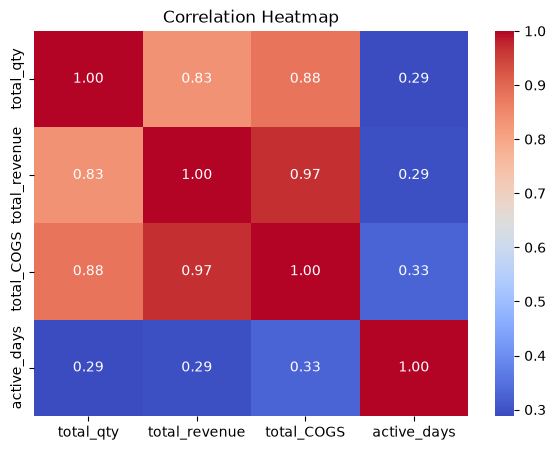

In [33]:
plt.figure(figsize=(7,5))

sns.heatmap(
    sku_summary.drop(columns="sku").corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### 3.5 Pareto Analysis (Top SKUs)

In [34]:
sku_summary = sku_summary.sort_values(
    "total_revenue",
    ascending=False
)

top20 = int(len(sku_summary) * 0.2)

top_skus = sku_summary.head(top20)

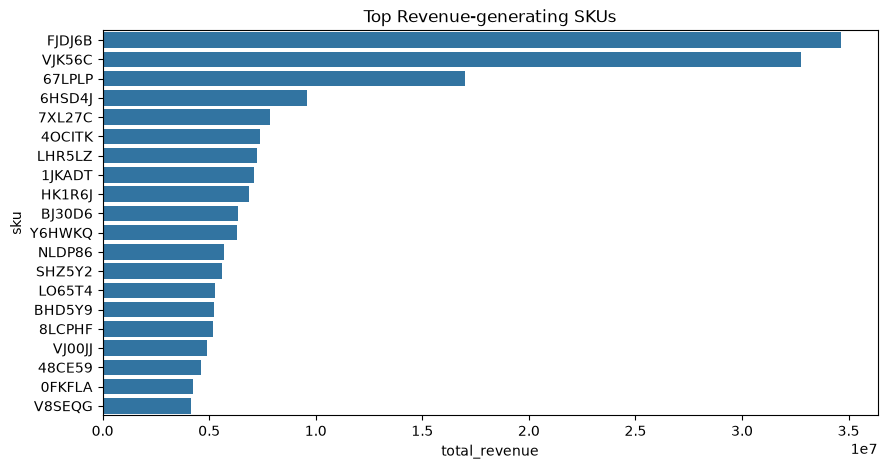

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_skus.head(20),
    x="total_revenue",
    y="sku"
)

plt.title("Top Revenue-generating SKUs")

plt.show()

### 3.6 Sales Quantity Distribution

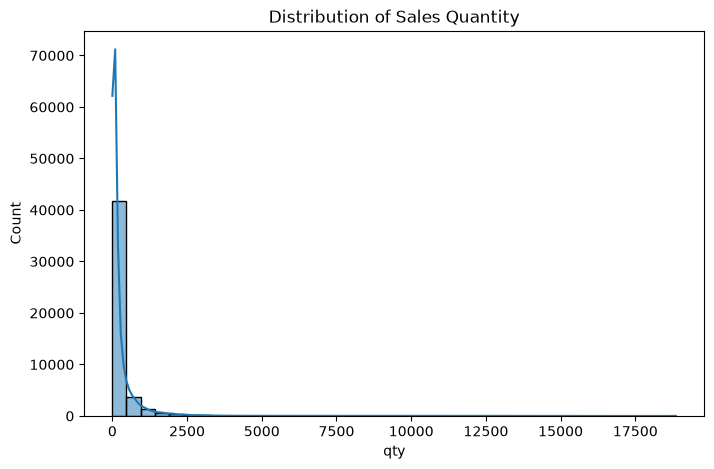

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_processed["qty"],
    bins=40,
    kde=True
)

plt.title("Distribution of Sales Quantity")

plt.show()

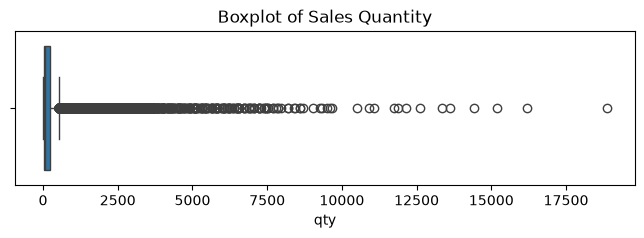

In [37]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_processed["qty"]
)

plt.title("Boxplot of Sales Quantity")

plt.show()

### 3.7 Sales Trend

#### Daily Sales

In [38]:
daily_sales = (
    df_processed
    .groupby("shipped_date")["qty"]
    .sum()
    .reset_index()
)

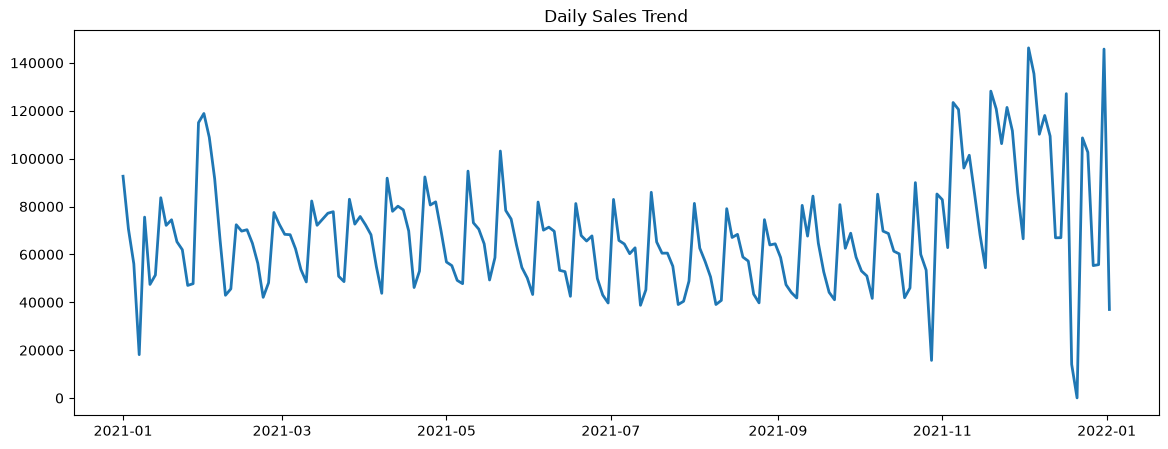

In [39]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_sales["shipped_date"],
    daily_sales["qty"],
    linewidth=2
)

plt.title("Daily Sales Trend")

plt.show()

#### Monthly Sales

In [40]:
monthly_sales = (
    df_processed
    .assign(month=df_processed["shipped_date"].dt.to_period("M"))
    .groupby("month")["qty"]
    .sum()
    .reset_index()
)

monthly_sales["month"] = monthly_sales["month"].astype(str)

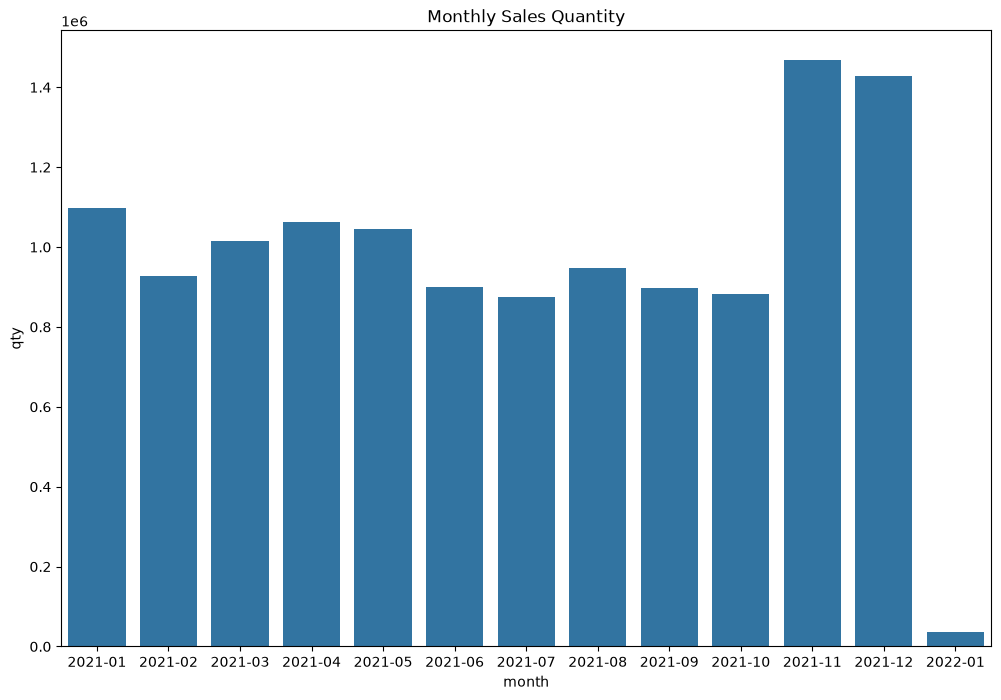

In [41]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=monthly_sales,
    x="month",
    y="qty"
)

plt.title("Monthly Sales Quantity")

plt.show()

## 4. Outlier Analysis

### 4.1 Statistical Summary

In [42]:
summary = (
    df_processed[["qty"]]
    .describe(
        percentiles=[0.1,0.25,0.5,0.75,0.9,0.99]
    )
)

summary

,qty
count,48345.000000
mean,260.406019
std,584.618564
min,0.000000
10%,19.000000
25%,34.000000
50%,80.000000
75%,238.000000
90%,638.800000
99%,2573.000000


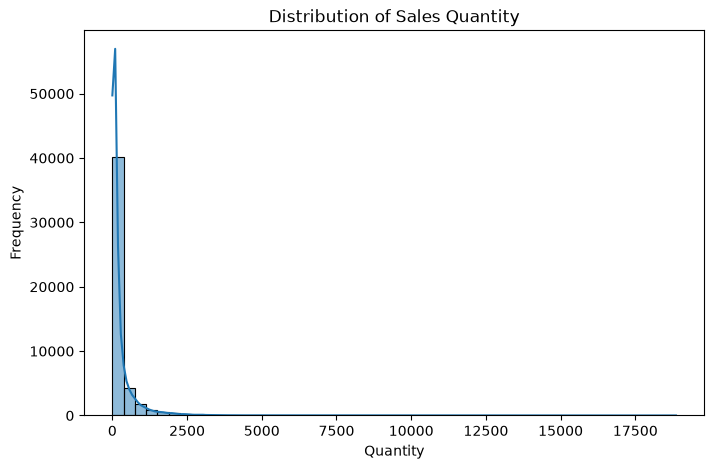

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_processed,
    x="qty",
    bins=50,
    kde=True
)

plt.title("Distribution of Sales Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

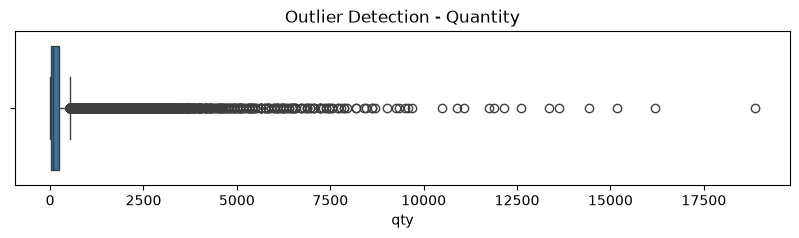

In [44]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_processed["qty"]
)

plt.title("Outlier Detection - Quantity")

plt.show()

In [45]:
df_outliers_corrected = correct_outliers(df_processed, factor=3)

In [46]:
print("Before:", df_processed.shape)
print("After :", df_outliers_corrected.shape)

Before: (48345, 7)
After : (48345, 7)


In [47]:
comparison = pd.DataFrame({
    "Before": df_processed["qty"].describe(),
    "After": df_outliers_corrected["qty"].describe()
})

comparison

,Before,After
count,48345.000000,48345.000000
mean,260.406019,205.022898
std,584.618564,308.075576
min,0.000000,0.000000
25%,34.000000,34.000000
50%,80.000000,80.000000
75%,238.000000,238.000000
max,18860.000000,2002.000000


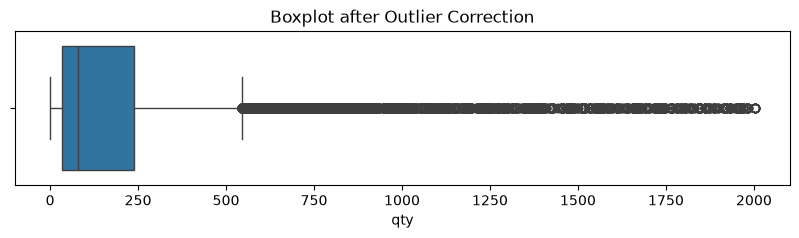

In [48]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_outliers_corrected["qty"]
)

plt.title("Boxplot after Outlier Correction")

plt.show()

### Outlier Handling

The Z-score method (threshold = 3) was applied to identify extreme observations in the `qty` column.

Instead of removing these records, the outlier values were replaced according to the project guideline to reduce their influence on the forecasting model while preserving the number of observations.

In [49]:
data_processed = df_outliers_corrected.copy()

In [51]:
data_processed.to_csv(
    "../data/processed/data_processed.csv",
    index=False
)